# Project 3: Credit Card Customer Segmentation with Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score

### Data Loading & Cleaning

Data Loading and Cleaning:  
   - Dropped unnecessary columns (Sl_No, Customer Key)
   - Handled missing values using median imputation
   - Removed outliers using the IQR method


In [2]:
df = pd.read_csv("data/credit_card.csv")
df.drop(["Sl_No", "Customer Key"], axis=1, inplace=True)
df.fillna(df.median(), inplace=True)

In [3]:
# Outlier detection (IQR Method)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

filter = ~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
df = df[filter]

### Feature Scaling

- Applied StandardScaler to normalize features before clustering

In [4]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

### K-Means Clustering

- Used K-Means with elbow method to determine k


In [5]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

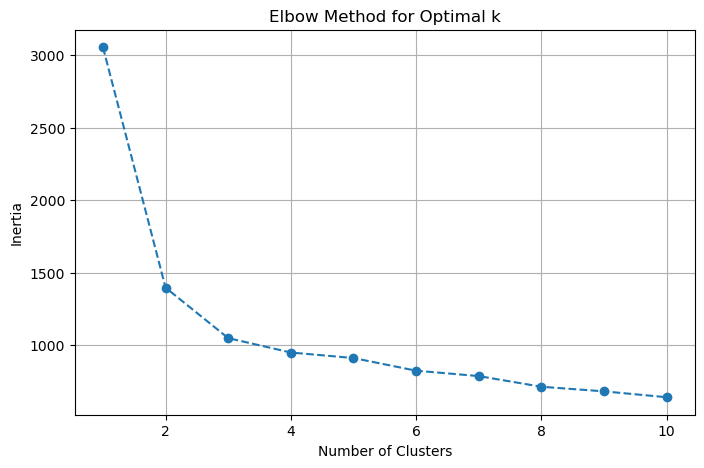

In [6]:
# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o", linestyle="--")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

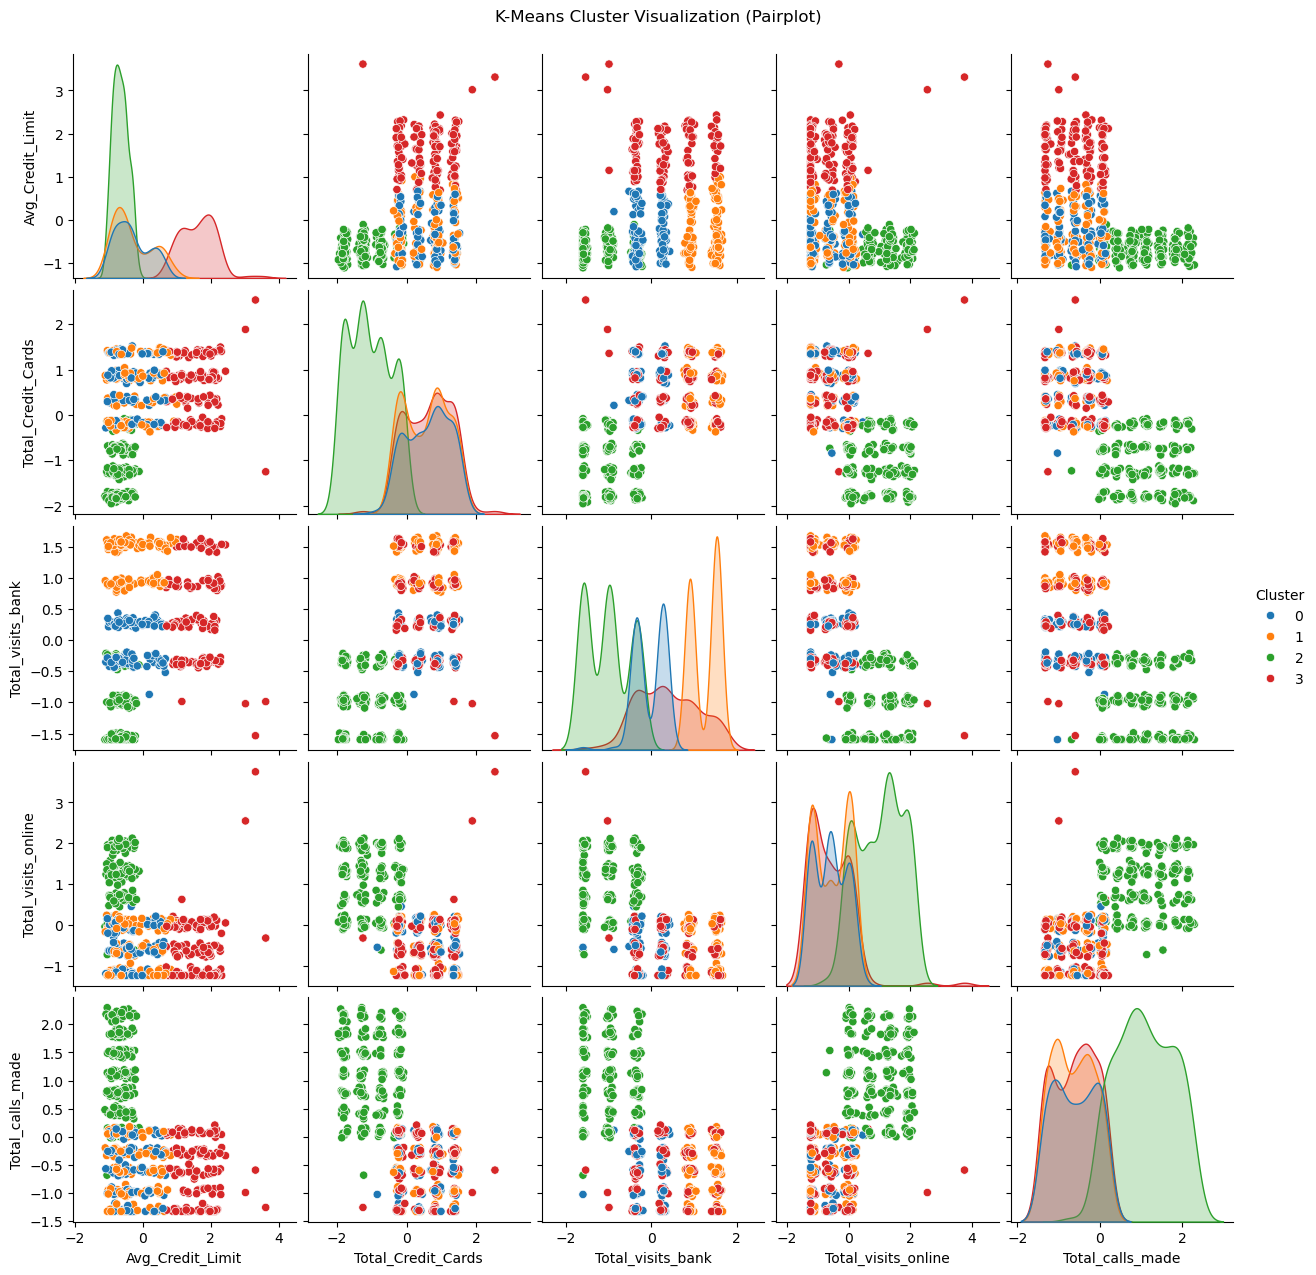

In [ ]:
# Model training and Visualization

# Applying K-Means with k=4 (assuming optimal from the elbow method)
kmeans = KMeans(n_clusters=4, random_state=42)
df_scaled["Cluster"] = kmeans.fit_predict(df_scaled)

# Pair plot
sns.pairplot(df_scaled, hue="Cluster", diag_kind="kde", palette="tab10")
plt.suptitle("K-Means Cluster Visualization (Pairplot)", y=1.02)
plt.show()

In [ ]:
# K-Means Clustering scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(
    df_scaled["Avg_Credit_Limit"],
    df_scaled["Total_visits_online"],
    c=df_scaled["Cluster"],
    cmap="tab10",
    alpha=0.6,
)
plt.title("K-Means Clustering: Avg_Credit_Limit vs Total_visits_online")
plt.xlabel("Avg_Credit_Limit")
plt.ylabel("Total_visits_online")
plt.grid(True)
plt.show()


### Hierarchical Clustering

- Used Agglomerative Clustering with dendrogram analysis

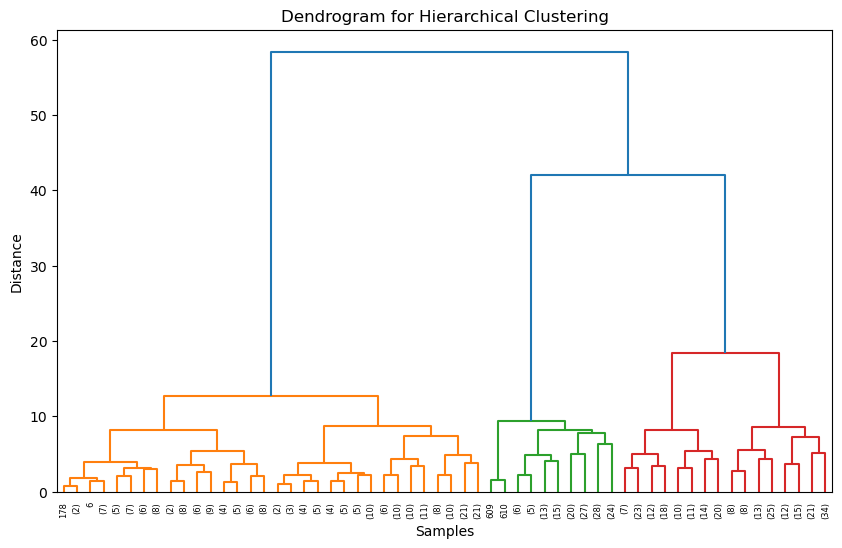

In [ ]:
# Generate linkage matrix for dendrogram
linked = linkage(df_scaled, method="ward")

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4)
df_scaled["Cluster_Hierarchical"] = agg.fit_predict(
    df_scaled.drop(columns=["Cluster"])
)

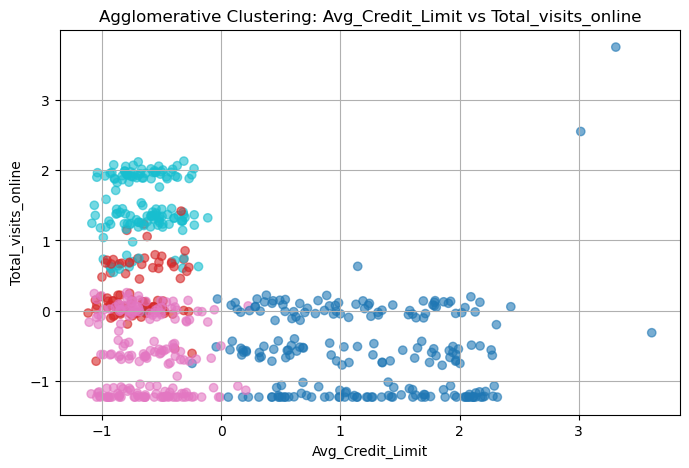

In [17]:
# Scatter plot

plt.figure(figsize=(8, 5))
plt.scatter(
    df_scaled["Avg_Credit_Limit"],
    df_scaled["Total_visits_online"],
    c=df_scaled["Cluster_Hierarchical"],
    cmap="tab10",
    alpha=0.6,
)
plt.title("Agglomerative Clustering: Avg_Credit_Limit vs Total_visits_online")
plt.xlabel("Avg_Credit_Limit")
plt.ylabel("Total_visits_online")
plt.grid(True)
plt.show()

### Evaluation & Visualization

- Visualized clusters using pair plots and 2D scatter plots  
- Evaluated models using:
    - Silhouette Score: higher is better
    - Davies-Bouldin Score: lower is better

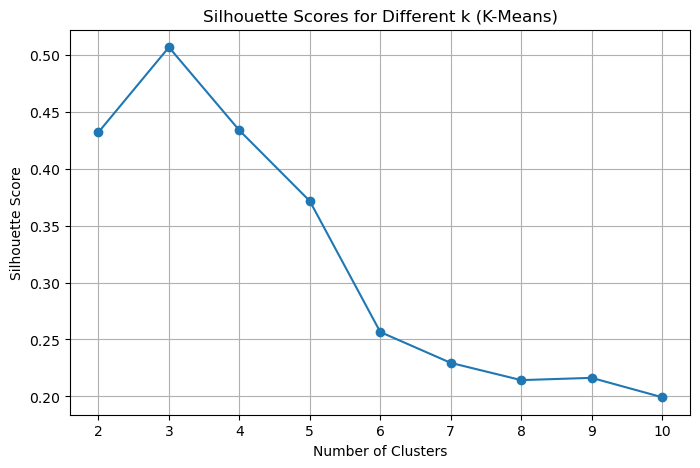

In [ ]:
# Calculate silhouette scores for different k values (1 to 10)
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(
        df_scaled.drop(columns=["Cluster_Hierarchical"], errors="ignore")
    )
    score = silhouette_score(
        df_scaled.drop(columns=["Cluster_Hierarchical"],
                       errors="ignore"), labels
    )
    silhouette_scores.append(score)

# Plot silhouette scores for each k
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker="o")
plt.title("Silhouette Scores for Different k (K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

Optimal number of clusters based on silhouette score: 3


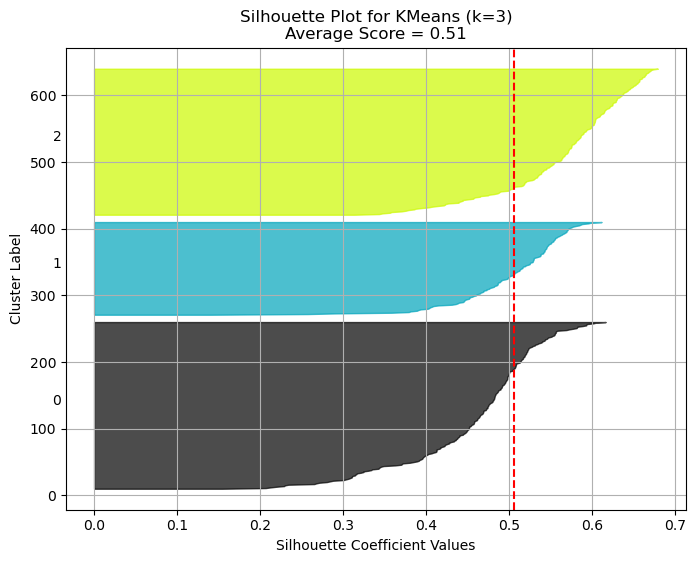

In [ ]:
# Select optimal k based on highest silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")

# Fit KMeans model with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(
    df_scaled.drop(columns=["Cluster_Hierarchical"], errors="ignore")
)

# Compute silhouette values
sample_silhouette_values = silhouette_samples(
    df_scaled.drop(columns=["Cluster_Hierarchical"],
                   errors="ignore"), cluster_labels
)
silhouette_avg = np.mean(sample_silhouette_values)

# Plot silhouette visualization
y_lower = 10
plt.figure(figsize=(8, 6))

for i in range(optimal_k):
    ith_cluster_silhouette_values = sample_silhouette_values
    [cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / optimal_k)
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.title(
    f"Silhouette Plot for KMeans (k={optimal_k})\n"
    f"Avg Score = {silhouette_avg:.2f}"
)
plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")
plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.grid(True)
plt.show()

In [ ]:
# KMeans Silhouette Score
score_kmeans = silhouette_score(
    df_scaled.drop(columns=["Cluster_Hierarchical"], errors="ignore"),
    df_scaled["Cluster"],
)

# Hierarchical Silhouette Score
score_hier = silhouette_score(
    df_scaled.drop(columns=["Cluster", "Cluster_Hierarchical"],
                   errors="ignore"),
    df_scaled["Cluster_Hierarchical"],
)

print(f"Silhouette Score (KMeans, k=4): {score_kmeans:.4f}")
print(f"Silhouette Score (Agglomerative Clustering): {score_hier:.4f}")

Silhouette Score (KMeans, k=4): 0.4336
Silhouette Score (Agglomerative Clustering): 0.2491


In [ ]:
# Davies-Bouldin Score for KMeans
db_kmeans = davies_bouldin_score(
    df_scaled.drop(columns=["Cluster", "Cluster_Hierarchical"],
                   errors="ignore"),
    df_scaled["Cluster"],
)

# Davies-Bouldin Score for Agglomerative Clustering
db_hier = davies_bouldin_score(
    df_scaled.drop(columns=["Cluster", "Cluster_Hierarchical"],
                   errors="ignore"),
    df_scaled["Cluster_Hierarchical"],
)

print(f"Davies-Bouldin Score (KMeans, k=4): {db_kmeans:.4f}")
print(f"Davies-Bouldin Score (Agglomerative Clustering): {db_hier:.4f}")

Davies-Bouldin Score (KMeans, k=4): 1.3335
Davies-Bouldin Score (Agglomerative Clustering): 1.5679


### Discussion

- How well did K-Means and Hierarchical Clustering segment the data?

K-Means did a better job at creating clear customer groups based on credit card usage. It had a higher silhouette score of 0.4336, while hierarchical clustering scored lower at 0.2491. The K-Means clusters like pink and cyan were easier to tell apart. There was still some overlap between red and blue, which shows the groups were not defined well. The clusters from Agglomerative Clustering were harder to tell apart in the scatter plot. Overall, K-Means found better patterns and made tighter, more separated groups.

- What challenges did you encounter in feature scaling and outlier detection?

Scaling the data with StandardScaler made sure that all columns were on the same scale and treated equally by the model. It was important to scale after fixing missing data. Removing outliers helped the model perform better, but it was tricky to do without removing useful data. Some extreme values might still carry important information, so it was important to find a good balance.

- How do silhouette and Davies-Bouldin scores help in cluster evaluation?

The silhouette score shows how well a point fits into its own cluster. Higher values mean better clustering. The Davies-Bouldin score checks how close and separate the clusters are. Lower scores mean the clusters are better. These scores help tell if the clustering made sense and if the model worked well.

- Compare and contrast results from the primary dataset and the secondary dataset.



